<a href="https://colab.research.google.com/github/jagdish1013/decodelabs_tasks/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv("creditcard.csv")

print(df.shape)

df.head()

(53571, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
print(df.info())

print(df.describe())

print(df["Class"].value_counts())

print(df["Class"].value_counts(normalize=True)*100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53571 entries, 0 to 53570
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    53571 non-null  int64  
 1   V1      53571 non-null  float64
 2   V2      53571 non-null  float64
 3   V3      53571 non-null  float64
 4   V4      53571 non-null  float64
 5   V5      53571 non-null  float64
 6   V6      53571 non-null  float64
 7   V7      53571 non-null  float64
 8   V8      53571 non-null  float64
 9   V9      53571 non-null  float64
 10  V10     53571 non-null  float64
 11  V11     53571 non-null  float64
 12  V12     53571 non-null  float64
 13  V13     53571 non-null  float64
 14  V14     53571 non-null  float64
 15  V15     53571 non-null  float64
 16  V16     53571 non-null  float64
 17  V17     53571 non-null  float64
 18  V18     53571 non-null  float64
 19  V19     53571 non-null  float64
 20  V20     53571 non-null  float64
 21  V21     53571 non-null  float64
 22

In [ ]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [ ]:
df.dropna(subset=['Class'], inplace=True)
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


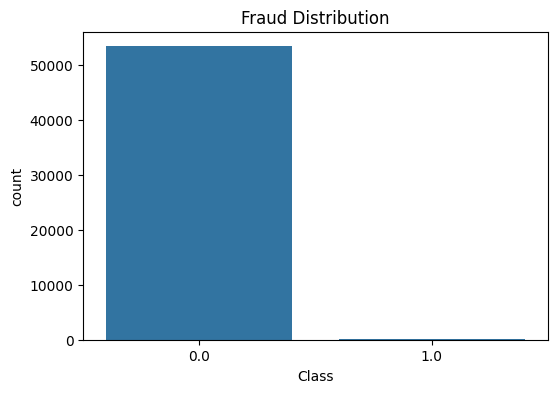

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Class",
    data=df
)

plt.title("Fraud Distribution")
plt.show()

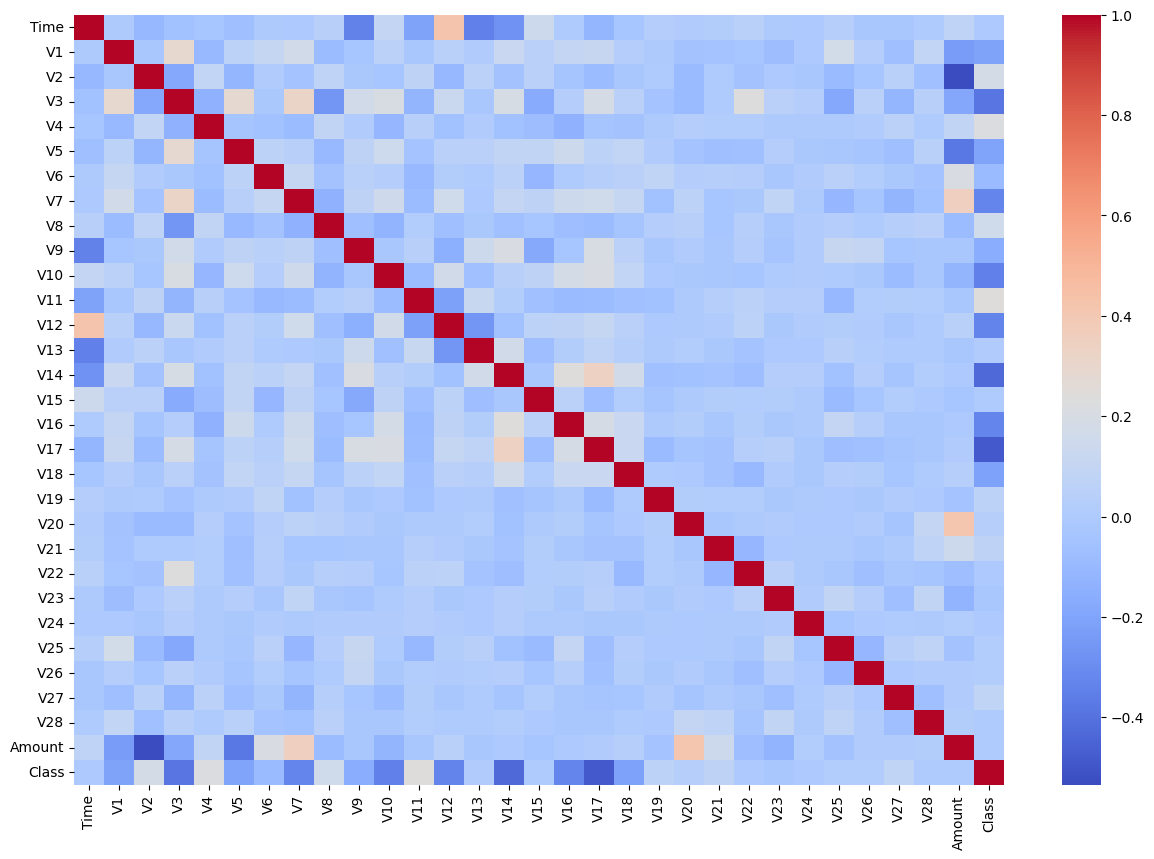

In [ ]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.show()

In [ ]:
X = df.drop("Class", axis=1)

y = df["Class"]

In [ ]:
X = df.drop("Class", axis=1)

y = df["Class"]

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(y_train.value_counts())
print(y_test.value_counts())

Class
0.0    42734
1.0      122
Name: count, dtype: int64
Class
0.0    10683
1.0       31
Name: count, dtype: int64


In [ ]:
print("Before SMOTE")

print(y_train.value_counts())

Before SMOTE
Class
0.0    42734
1.0      122
Name: count, dtype: int64


In [ ]:
lr_pipeline = Pipeline([

    ("scaler", StandardScaler()),

    ("smote", SMOTE(
        random_state=42
    )),

    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [ ]:
lr_pipeline = Pipeline([

    ("scaler", StandardScaler()),

    ("smote", SMOTE(
        random_state=42
    )),

    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [ ]:
lr_params = {

    "smote__k_neighbors":[3,5,7],

    "classifier__C":[
        0.01,
        0.1,
        1,
        10
    ]
}

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_grid = GridSearchCV(

    estimator=lr_pipeline,

    param_grid=lr_params,

    scoring="roc_auc",

    cv=cv,

    n_jobs=-1,

    verbose=2
)

lr_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'smote__k_neighbors': [3, 5, 7]},
             scoring='roc_auc', verbose=2)

In [ ]:
print(
    lr_grid.best_params_
)

print(
    lr_grid.best_score_
)

{'classifier__C': 10, 'smote__k_neighbors': 3}
0.9765480058672195


In [ ]:
lr_pred = lr_grid.predict(
    X_test
)

lr_prob = lr_grid.predict_proba(
    X_test
)[:,1]

In [ ]:
precision = precision_score(
    y_test,
    lr_pred
)

recall = recall_score(
    y_test,
    lr_pred
)

roc_auc = roc_auc_score(
    y_test,
    lr_prob
)

print("Precision :", precision)
print("Recall :", recall)
print("ROC AUC :", roc_auc)

print(
    classification_report(
        y_test,
        lr_pred
    )
)

Precision : 0.16374269005847952
Recall : 0.9032258064516129
ROC AUC : 0.9665794010985195
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     10683
         1.0       0.16      0.90      0.28        31

    accuracy                           0.99     10714
   macro avg       0.58      0.94      0.64     10714
weighted avg       1.00      0.99      0.99     10714



In [ ]:
rf_pipeline = Pipeline([

    (
        "smote",
        SMOTE(
            random_state=42
        )
    ),

    (
        "classifier",
        RandomForestClassifier(
            random_state=42
        )
    )
])

In [ ]:
rf_params = {

    "smote__k_neighbors":[

        5

    ],

    "classifier__n_estimators":[
        100,
        200
    ],

    "classifier__max_depth":[
        10,
        20,
        None
    ]
}

In [ ]:

rf_grid = GridSearchCV(

    estimator=rf_pipeline,

    param_grid=rf_params,

    scoring="roc_auc",

    cv=cv,

    n_jobs=-1,

    verbose=2
)

rf_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [10, 20, None],
                         'classifier__n_estimators': [100, 200],
                         'smote__k_neighbors': [5]},
             scoring='roc_auc', verbose=2)

In [ ]:
print(
    rf_grid.best_params_
)

print(
    rf_grid.best_score_
)

{'classifier__max_depth': 10, 'classifier__n_estimators': 100, 'smote__k_neighbors': 5}
0.9904697471275987


In [ ]:
rf_pred = rf_grid.predict(
    X_test
)

rf_prob = rf_grid.predict_proba(
    X_test
)[:,1]

In [ ]:
precision = precision_score(
    y_test,
    rf_pred
)

recall = recall_score(
    y_test,
    rf_pred
)

roc_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("Precision :", precision)
print("Recall :", recall)
print("ROC AUC :", roc_auc)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Precision : 0.6590909090909091
Recall : 0.9354838709677419
ROC AUC : 0.997004586726575
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     10683
         1.0       0.66      0.94      0.77        31

    accuracy                           1.00     10714
   macro avg       0.83      0.97      0.89     10714
weighted avg       1.00      1.00      1.00     10714



In [ ]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Precision":[

        precision_score(
            y_test,
            lr_pred
        ),

        precision_score(
            y_test,
            rf_pred
        )
    ],

    "Recall":[

        recall_score(
            y_test,
            lr_pred
        ),

        recall_score(
            y_test,
            rf_pred
        )
    ],

    "ROC_AUC":[

        roc_auc_score(
            y_test,
            lr_prob
        ),

        roc_auc_score(
            y_test,
            rf_prob
        )
    ]
})

results

,Model,Precision,Recall,ROC_AUC
0,Logistic Regression,0.163743,0.903226,0.966579
1,Random Forest,0.659091,0.935484,0.997005


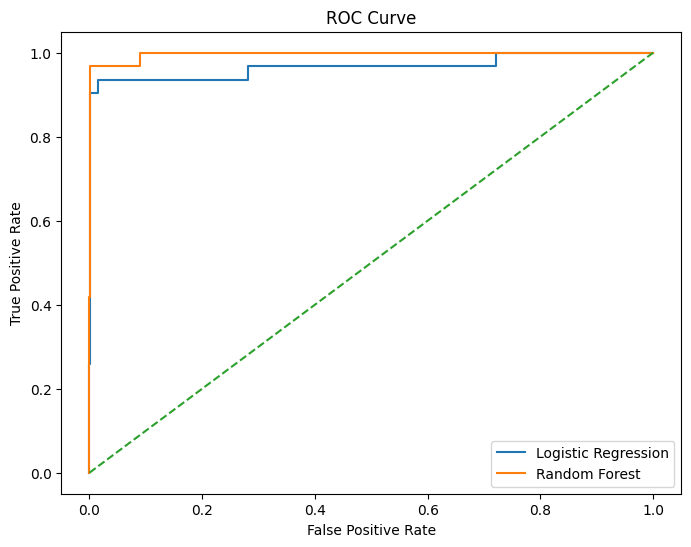

In [ ]:
lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    lr_prob
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label="Logistic Regression"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

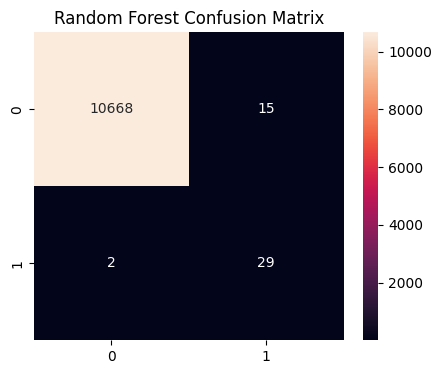

In [ ]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()